In [19]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [20]:
def load_and_preprocess_data():
    """Fetches the MNIST dataset and prepares raw labels for Multiclass OvA."""
    print("Fetching MNIST dataset")
    mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto')
    
    # Normalize features to [0, 1]
    X = mnist.data.values.astype('float32') / 255.0
    y = mnist.target.values.astype('int')
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=42)
    print(f"Data loaded: X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train_raw, y_test_raw = load_and_preprocess_data()

Fetching MNIST dataset
Data loaded: X_train shape: (60000, 784), X_test shape: (10000, 784)


In [21]:
def train_voted_perceptron_multiclass(X_train, y_train, d=1, epochs=1):
    """
    True Multiclass Voted Perceptron (Dual Form)
    Maintains a single, global timeline of mistakes across all classes.
    """
    print(f"Training Multiclass | d={d}, Epochs={epochs}")
    start_train_time = time.time()
    
    n_samples, n_features = X_train.shape
    n_classes = len(np.unique(y_train))
    
    # Pre-allocate static arrays to eliminate list-append overhead
    max_possible_mistakes = n_samples * epochs + 1
    
    M_x = np.zeros((max_possible_mistakes, n_features), dtype=X_train.dtype)
    M_y_true = np.zeros(max_possible_mistakes, dtype=int)
    M_y_pred = np.zeros(max_possible_mistakes, dtype=int)
    c_array = np.zeros(max_possible_mistakes, dtype=int)
    
    k = 0 # Tracks our current index AND the total number of mistakes
    c = 0 # Survival counter
    
    for epoch in range(epochs):
        for i in range(n_samples):
            x_i = X_train[i]
            y_i = y_train[i]
            
            scores = np.zeros(n_classes)
            
            if k > 0:
                # Kernel trick: compute against ONLY the recorded mistakes so far
                K_vec = (1 + np.dot(M_x[:k], x_i)) ** d
                
                # Vectorized score update
                np.add.at(scores, M_y_true[:k], K_vec)
                np.subtract.at(scores, M_y_pred[:k], K_vec)
                    
            y_pred = np.argmax(scores)
            
            if y_pred == y_i:
                c += 1
            else:
                # Record the global mistake
                c_array[k] = c
                M_x[k] = x_i
                M_y_true[k] = y_i
                M_y_pred[k] = y_pred
                
                k += 1
                c = 1
                
    # Record the final survival count
    c_array[k] = c
    total_mistakes = k 
    
    print(f"  > Training completed in {time.time() - start_train_time:.1f}s | Total mistakes: {total_mistakes}")
    
    # Return trimmed views of the arrays
    return M_x[:k], M_y_true[:k], M_y_pred[:k], c_array[:k+1], total_mistakes

In [22]:
def evaluate_multiclass(X_test, y_test, M_x, M_y_true, M_y_pred, c_list, d=1):
    """
    Evaluates the True Multiclass model.
    Tracks global argmax shifts to calculate Survival-Weighted Streak and Margin.
    """
    start_eval_time = time.time()
    n_samples = len(X_test)
    n_classes = 10
    n_mistakes = len(M_x)
    
    y_pred_final = np.zeros(n_samples, dtype=int)
    conf_weighted = np.zeros(n_samples)
    conf_streak = np.zeros(n_samples, dtype=int)
    mistakes_mask = np.zeros(n_samples, dtype=bool)
    
    batch_size = 1000
    
    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        X_batch = X_test[start_idx:end_idx]
        
        if n_mistakes > 0:
            K_batch = (1 + np.dot(X_batch, M_x.T)) ** d
        else:
            K_batch = np.zeros((len(X_batch), 0))
            
        for i, i_global in enumerate(range(start_idx, end_idx)):
            if n_mistakes > 0:
                K_vec = K_batch[i]
                
                # Reconstruct update matrix
                update_matrix = np.zeros((n_mistakes, n_classes))
                update_matrix[np.arange(n_mistakes), M_y_true] += K_vec
                update_matrix[np.arange(n_mistakes), M_y_pred] -= K_vec
                
                # Reconstruct cumulative scores for all historical models
                hypothesis_scores = np.zeros((n_mistakes + 1, n_classes))
                hypothesis_scores[1:] = np.cumsum(update_matrix, axis=0)
                
                # Get the global predicted class from every single historical step
                preds = np.argmax(hypothesis_scores, axis=1)
                
                # --------------------------------------------------------------
                # 1. SURVIVAL-WEIGHTED UNBROKEN STREAK
                # --------------------------------------------------------------
                last_pred = preds[-1]
                diff_indices = np.where(preds != last_pred)[0]
                
                # Find the index right after it last changed its mind
                streak_start_idx = 0 if len(diff_indices) == 0 else diff_indices[-1] + 1
                
                # Sum the survival weights of that unbroken sequence
                conf_streak[i_global] = np.sum(c_list[streak_start_idx:])
                
                # --------------------------------------------------------------
                # 2. SURVIVAL-WEIGHTED VOTE MARGIN
                # --------------------------------------------------------------
                weighted_votes = np.bincount(preds, weights=c_list, minlength=n_classes)
                final_pred = np.argmax(weighted_votes)
                y_pred_final[i_global] = final_pred
                
                sorted_votes = np.sort(weighted_votes)
                conf_weighted[i_global] = sorted_votes[-1] - sorted_votes[-2]
                
            else:
                final_pred = 0
                y_pred_final[i_global] = 0
                conf_weighted[i_global] = 0
                conf_streak[i_global] = 0
                
            if final_pred != y_test[i_global]:
                mistakes_mask[i_global] = True
                
    print(f"  > Evaluation Complete in {time.time() - start_eval_time:.1f}s")
    return conf_streak, conf_weighted, mistakes_mask

In [23]:
def get_error_rates(confidences, mistakes):
    """Calculates error rates across confidence thresholds."""
    thresholds = np.linspace(np.min(confidences), np.max(confidences), 100)
    error_rates = []
    
    for t in thresholds:
        keep_mask = confidences >= t
        retained = np.sum(keep_mask)
        
        if retained > 20: 
            error_rate = np.mean(mistakes[keep_mask]) * 100
            error_rates.append(error_rate)
        else:
            error_rates.append(np.nan)
            
    return thresholds, error_rates

In [24]:
def plot_calibration_multiclass(conf_streak, conf_weighted, mistakes_mask, d):
    """Generates a 1x2 calibration profile comparing Streak vs Weighted Confidence."""
    t_streak, err_streak = get_error_rates(conf_streak, mistakes_mask)
    t_weight, err_weight = get_error_rates(conf_weighted, mistakes_mask)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    bbox_props = dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="orange", lw=1.5, alpha=0.9)

    # --- PLOT 1: UNBROKEN STREAK ---
    axes[0].plot(t_streak, err_streak, 'r-', linewidth=2.5)
    axes[0].set_xlabel('Threshold (Survival-Weighted Streak)')
    axes[0].set_ylabel('Error Rate (%)', fontsize=12)
    axes[0].set_title('1. True Multiclass Unbroken Streak\n(Survival sum of the final unbroken sequence)', pad=15, fontsize=14)
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # --- PLOT 2: SURVIVAL-WEIGHTED CONFIDENCE ---
    axes[1].plot(t_weight, err_weight, 'g-', linewidth=2.5)
    axes[1].set_xlabel('Threshold (Margin of Victory)')
    axes[1].set_ylabel('Error Rate (%)', fontsize=12)
    axes[1].set_title('2. Survival-Weighted Margin\n(Difference between 1st and 2nd place)', pad=15, fontsize=14)
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.suptitle(f"Evaluating Confidence: True Multiclass Kernel Voted Perceptron (d={d})", 
                 fontsize=16, fontweight='bold', y=1.05)
    
    plt.tight_layout() 
    plt.show()

In [25]:
def plot_distributions(conf_streak, conf_weighted, d):
    """Generates Histograms and CDFs for the test set confidence metrics."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # --- ROW 1: UNBROKEN STREAK ---
    # Histogram
    axes[0, 0].hist(conf_streak, bins=1000, color='crimson')
    axes[0, 0].set_xlabel('Unbroken Streak Length')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('1A. Unbroken Streak (Histogram)', pad=15, fontsize=14)
    axes[0, 0].grid(True, linestyle='--', alpha=0.7)

    # CDF
    data_streak = np.sort(conf_streak)
    cdf_streak = np.arange(1, len(data_streak) + 1) / len(data_streak)
    axes[0, 1].plot(data_streak, cdf_streak, '.', color='red')
    axes[0, 1].set_xlabel('Unbroken Streak Length')
    axes[0, 1].set_ylabel('CDF')
    axes[0, 1].set_title('1B. CDF via Sorting: Unbroken Streak', pad=15, fontsize=14)
    axes[0, 1].grid(True, linestyle='--', alpha=0.7)

    # --- ROW 2: SURVIVAL-WEIGHTED MARGIN ---
    # Histogram
    axes[1, 0].hist(conf_weighted, bins=1000, color='royalblue')
    axes[1, 0].set_xlabel('Margin of Victory (Votes)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('2A. Survival-Weighted Margin (Histogram)', pad=15, fontsize=14)
    axes[1, 0].grid(True, linestyle='--', alpha=0.7)

    # CDF
    data_weight = np.sort(conf_weighted)
    cdf_weight = np.arange(1, len(data_weight) + 1) / len(data_weight)
    axes[1, 1].plot(data_weight, cdf_weight, '.', color='blue')
    axes[1, 1].set_xlabel('Margin of Victory (Votes)')
    axes[1, 1].set_ylabel('CDF')
    axes[1, 1].set_title('2B. CDF via Sorting: Weighted Margin', pad=15, fontsize=14)
    axes[1, 1].grid(True, linestyle='--', alpha=0.7)

    plt.suptitle(f"Test Set Distributions: Confidence Metrics (d={d})", 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout() 
    plt.show()

In [26]:
def plot_rejection_vs_error(conf_streak, conf_weighted, mistakes_mask, d):
    """
    Plots the trade-off between the percentage of data rejected and the error rate 
    on the remaining data for both confidence metrics.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    metrics = [
        (conf_streak, 'r-', 'Unbroken Streak'),
        (conf_weighted, 'g-', 'Weighted Margin')
    ]
    
    total_samples = len(mistakes_mask)
    
    for i, (confidences, color, label) in enumerate(metrics):
        thresholds = np.linspace(np.min(confidences), np.max(confidences), 200)
        rejection_rates = []
        error_rates = []
        
        for t in thresholds:
            keep_mask = confidences >= t
            retained = np.sum(keep_mask)
            rejected = total_samples - retained
            
            if retained > 20: 
                rejection_rates.append((rejected / total_samples) * 100.0)
                error_rates.append(np.mean(mistakes_mask[keep_mask]) * 100.0)
                
        axes[i].plot(rejection_rates, error_rates, color, linewidth=3, label=label)
        
        # Mark the baseline
        if len(error_rates) > 0:
            baseline_err = error_rates[0]
            axes[i].scatter([0], [baseline_err], color='black', zorder=5)
            axes[i].annotate(f'Base Error: {baseline_err:.2f}%', (0, baseline_err), 
                             textcoords="offset points", xytext=(10, 10), ha='left', fontsize=11)
            
        axes[i].set_xlabel('Data Given Up / Rejection Rate (%)', fontsize=12)
        axes[i].set_ylabel('Error Rate on Remaining Data (%)', fontsize=12)
        axes[i].set_title(f'Trade-off: {label}', pad=10, fontsize=14)
        axes[i].grid(True, linestyle='--', alpha=0.7)
        axes[i].legend()

    plt.suptitle(f"Accuracy-Rejection Trade-off Curves (d={d})", 
                 fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

Fetching MNIST dataset
Data loaded: X_train shape: (60000, 784), X_test shape: (10000, 784)

Training Multiclass | d=1, Epochs=1
  > Training completed in 65.1s | Total mistakes: 9089
  > Evaluation Complete in 8.7s
  > Test Set Accuracy: 91.75%


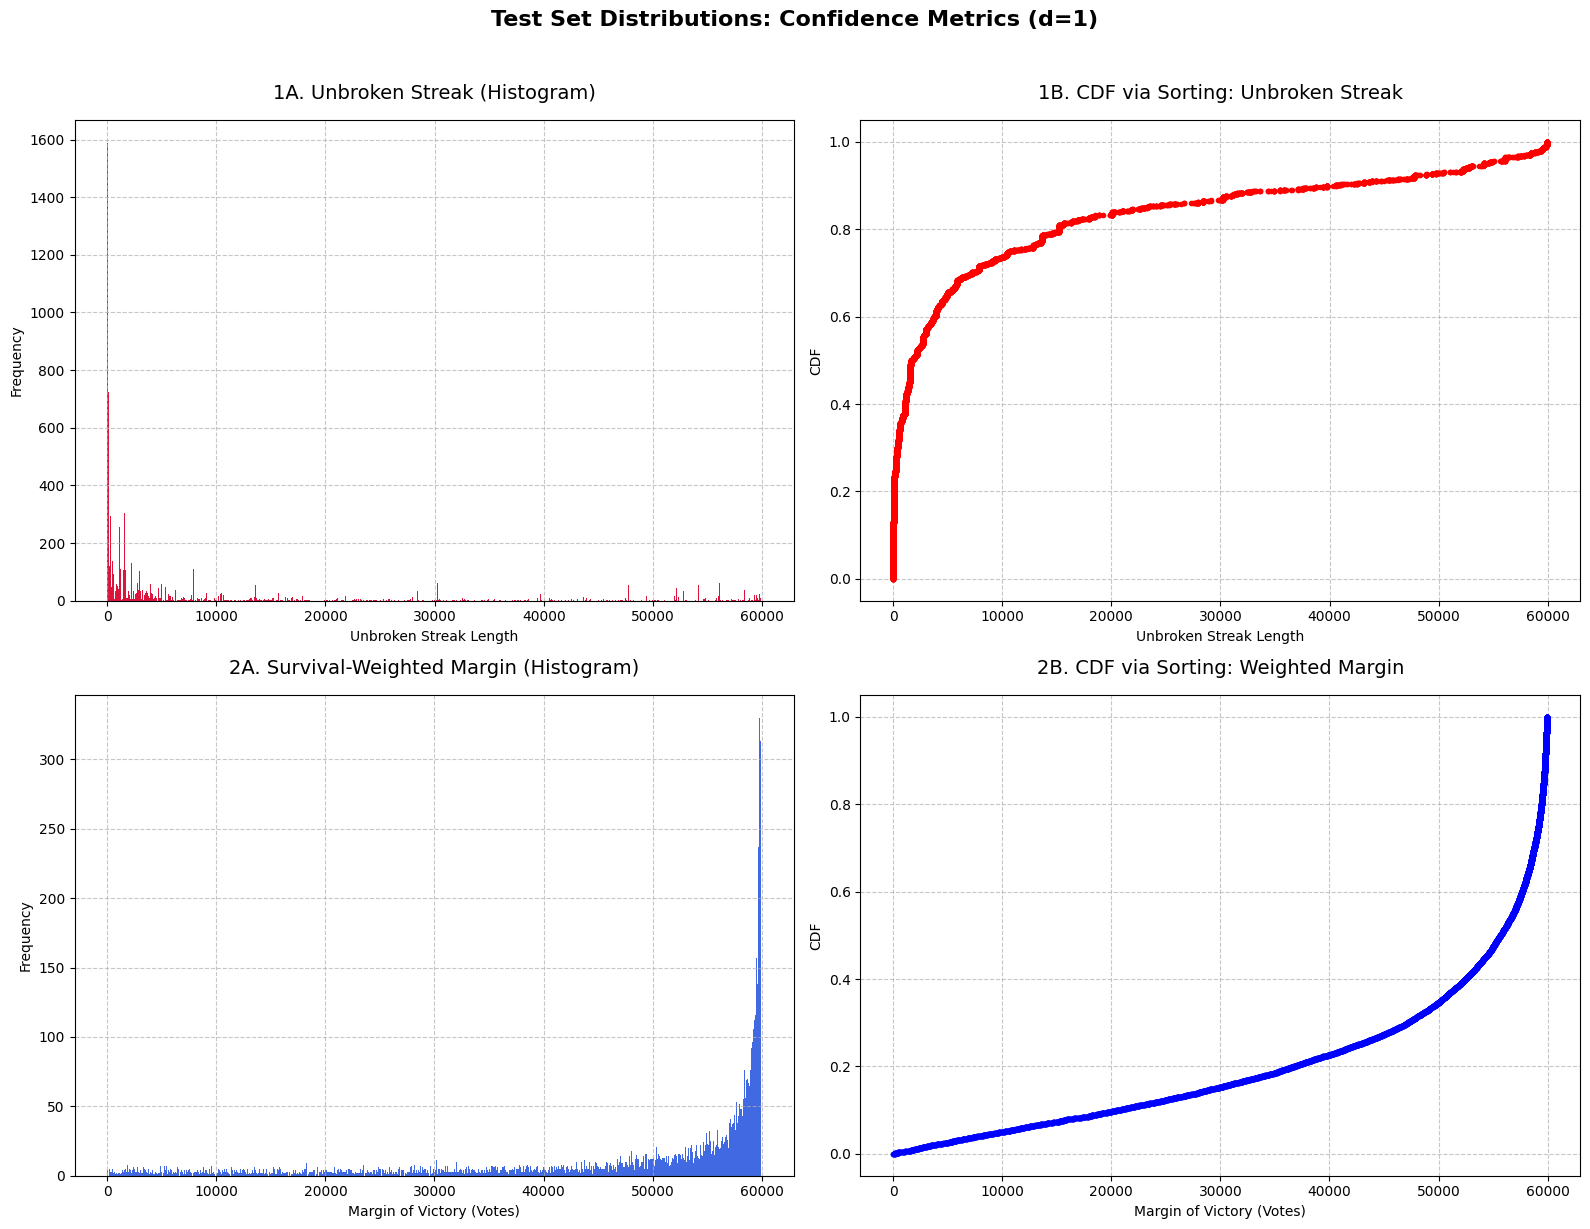

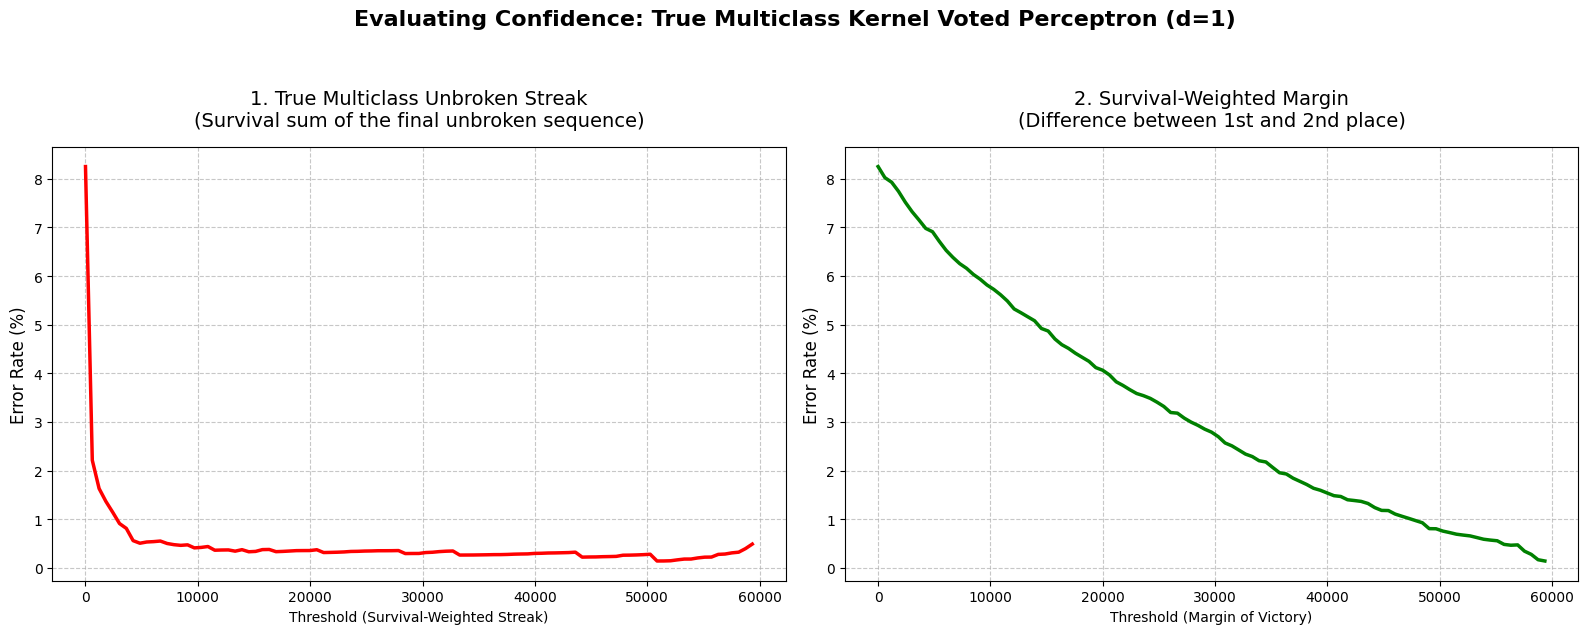

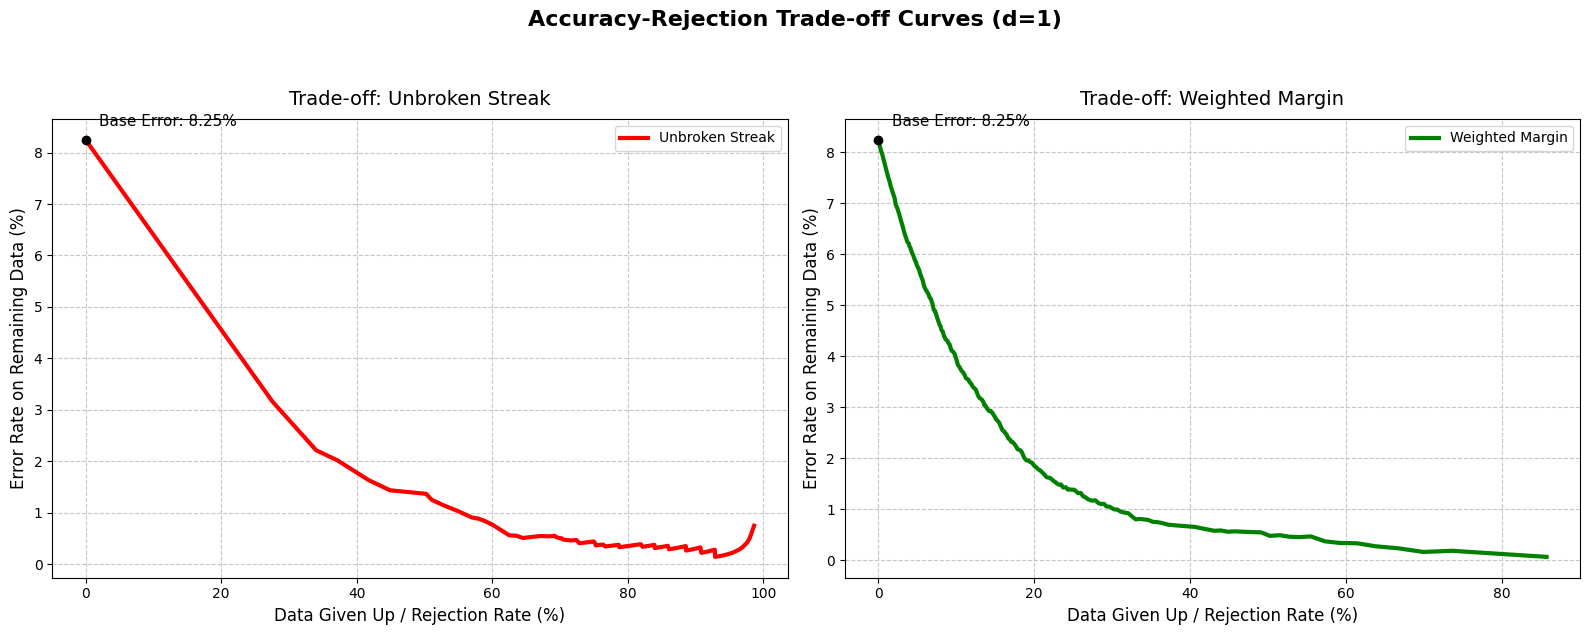


Training Multiclass | d=2, Epochs=1
  > Training completed in 40.4s | Total mistakes: 4357
  > Evaluation Complete in 4.4s
  > Test Set Accuracy: 96.76%


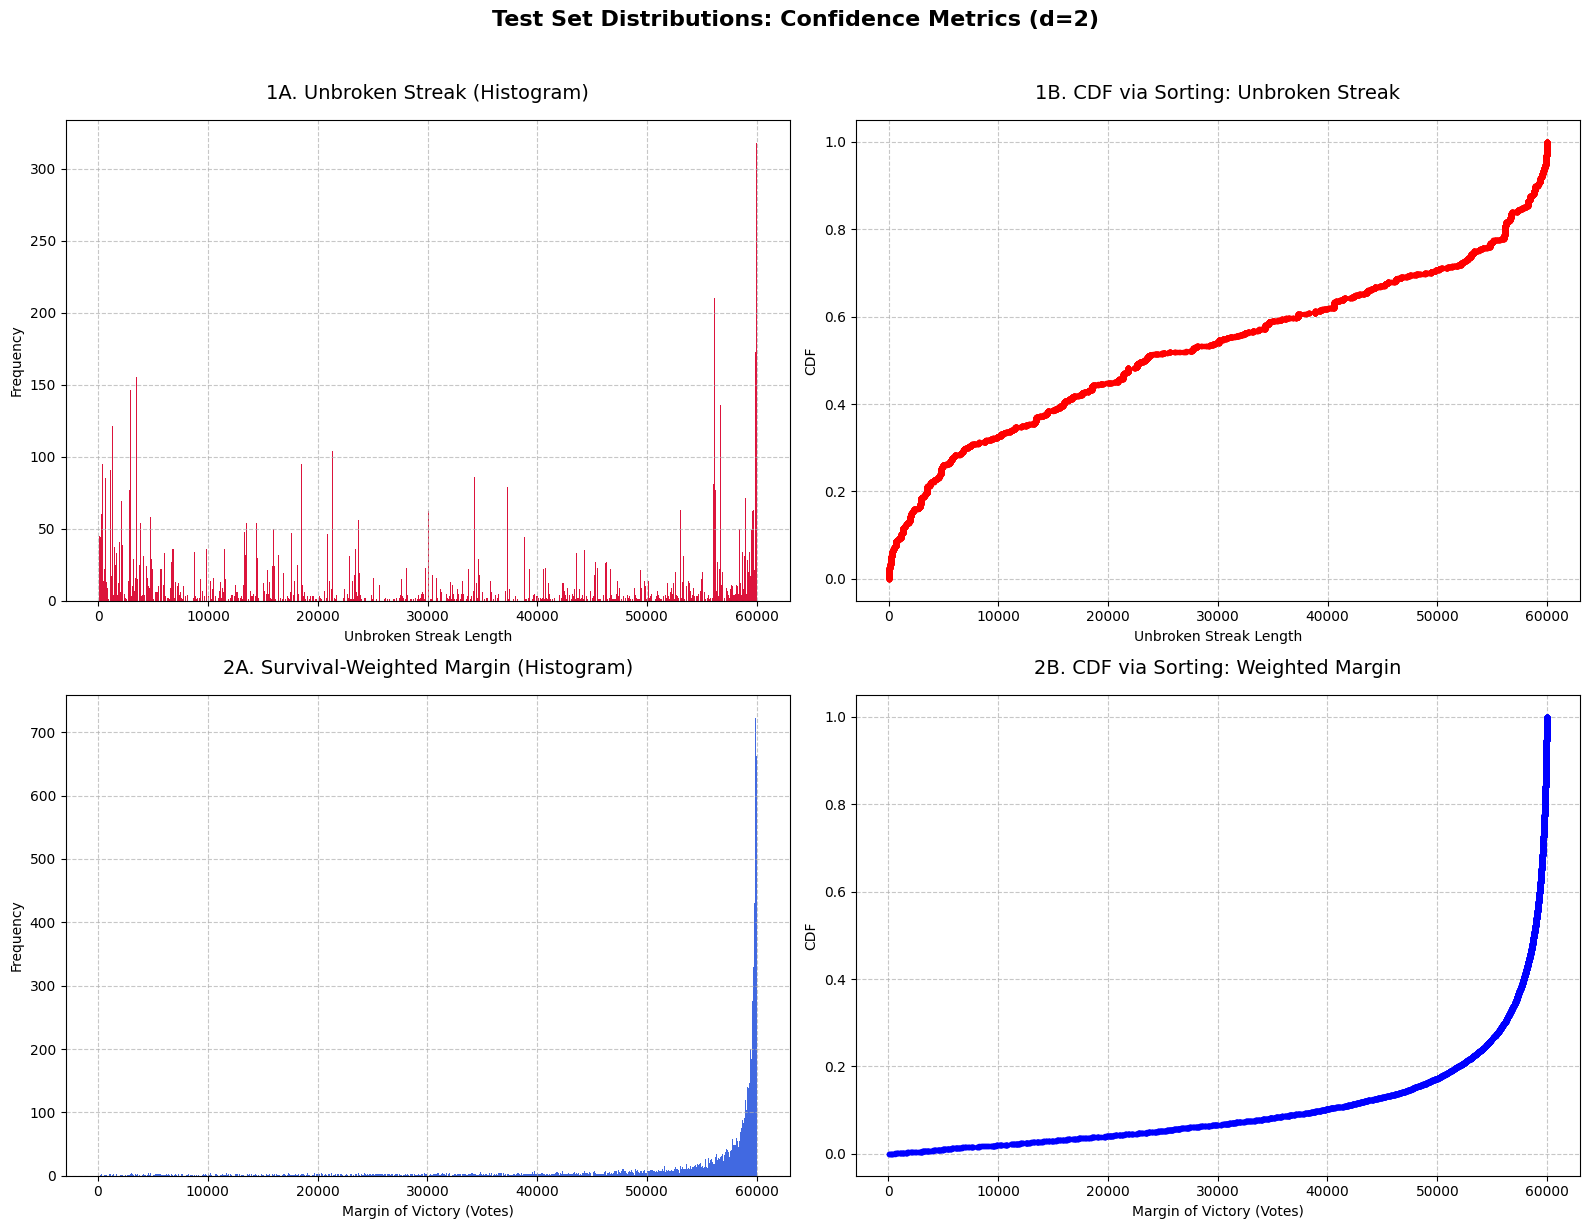

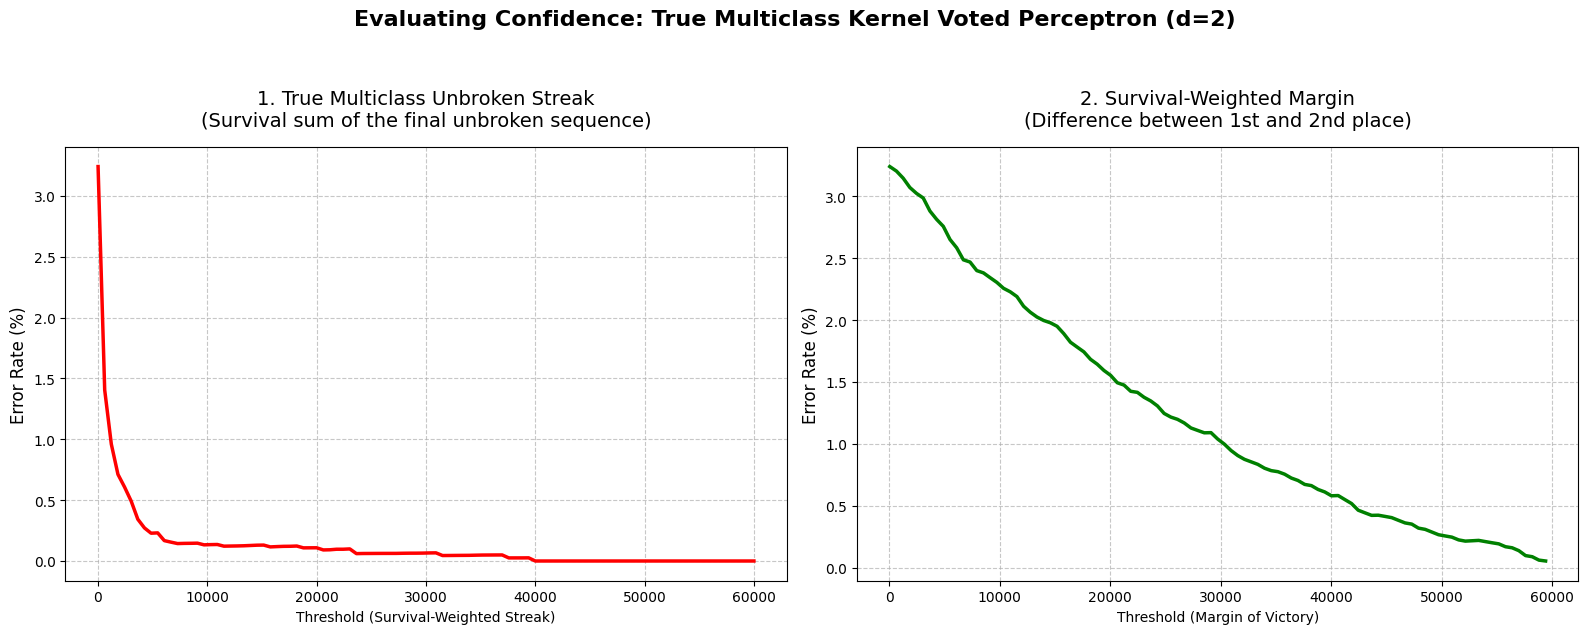

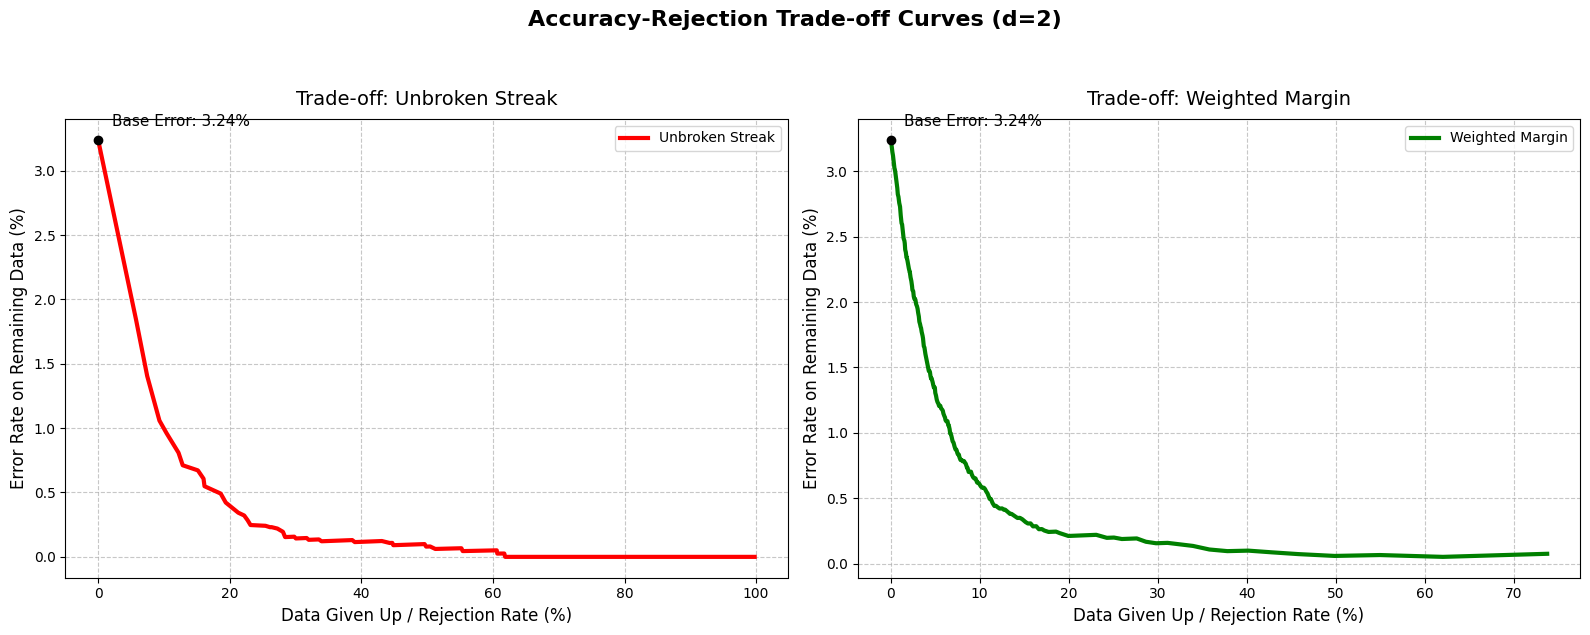


Training Multiclass | d=3, Epochs=1
  > Training completed in 37.5s | Total mistakes: 3559
  > Evaluation Complete in 4.0s
  > Test Set Accuracy: 97.11%


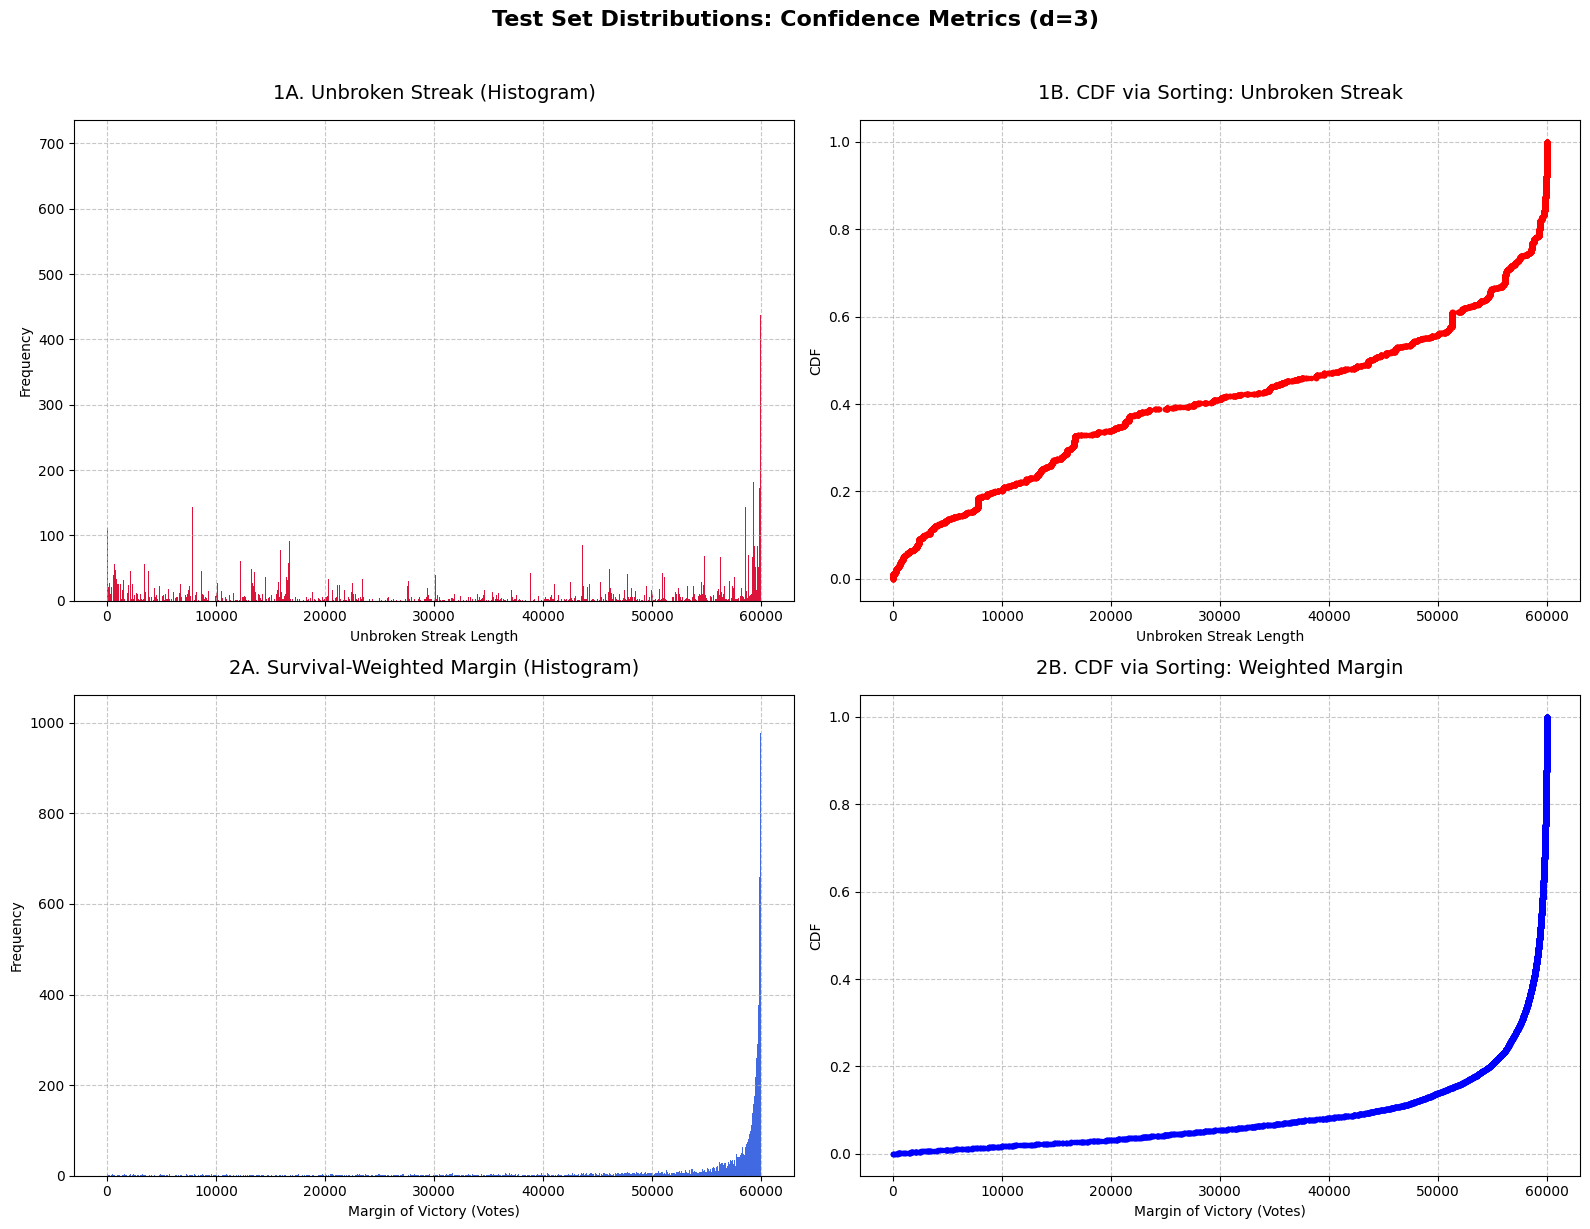

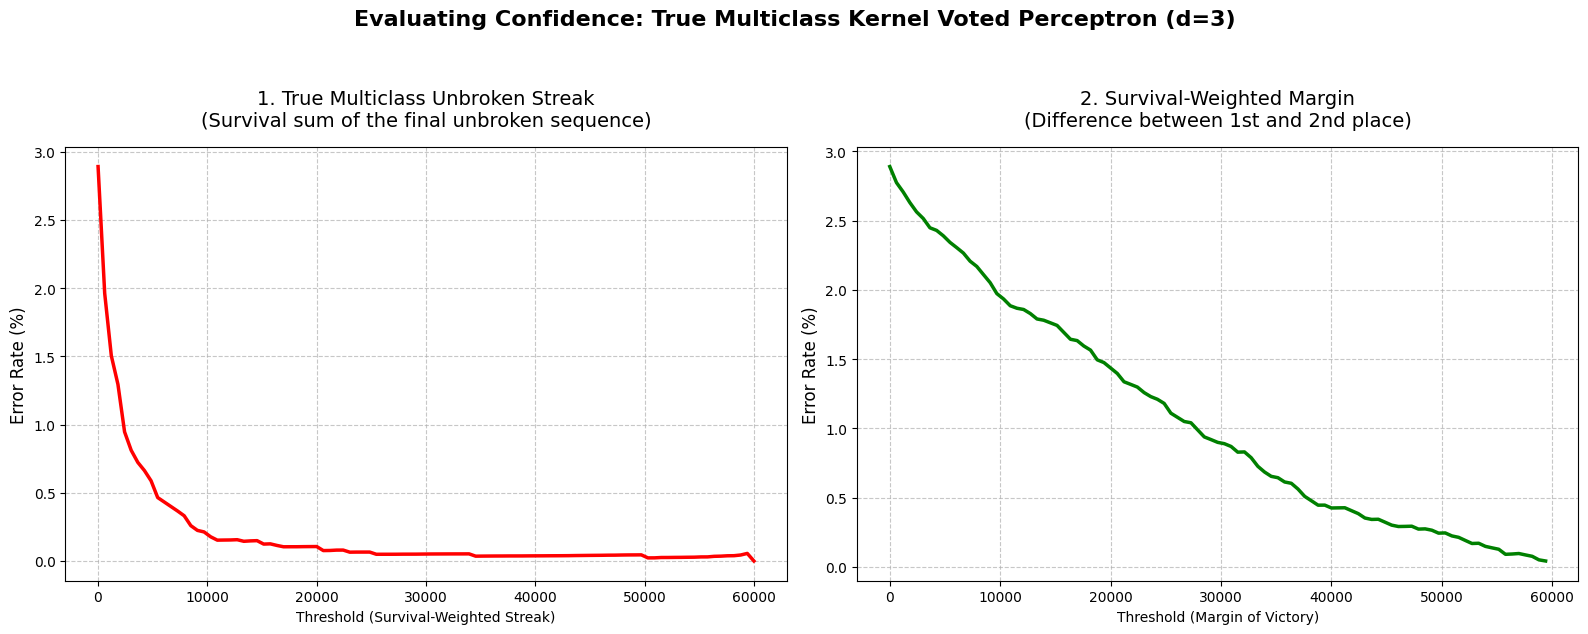

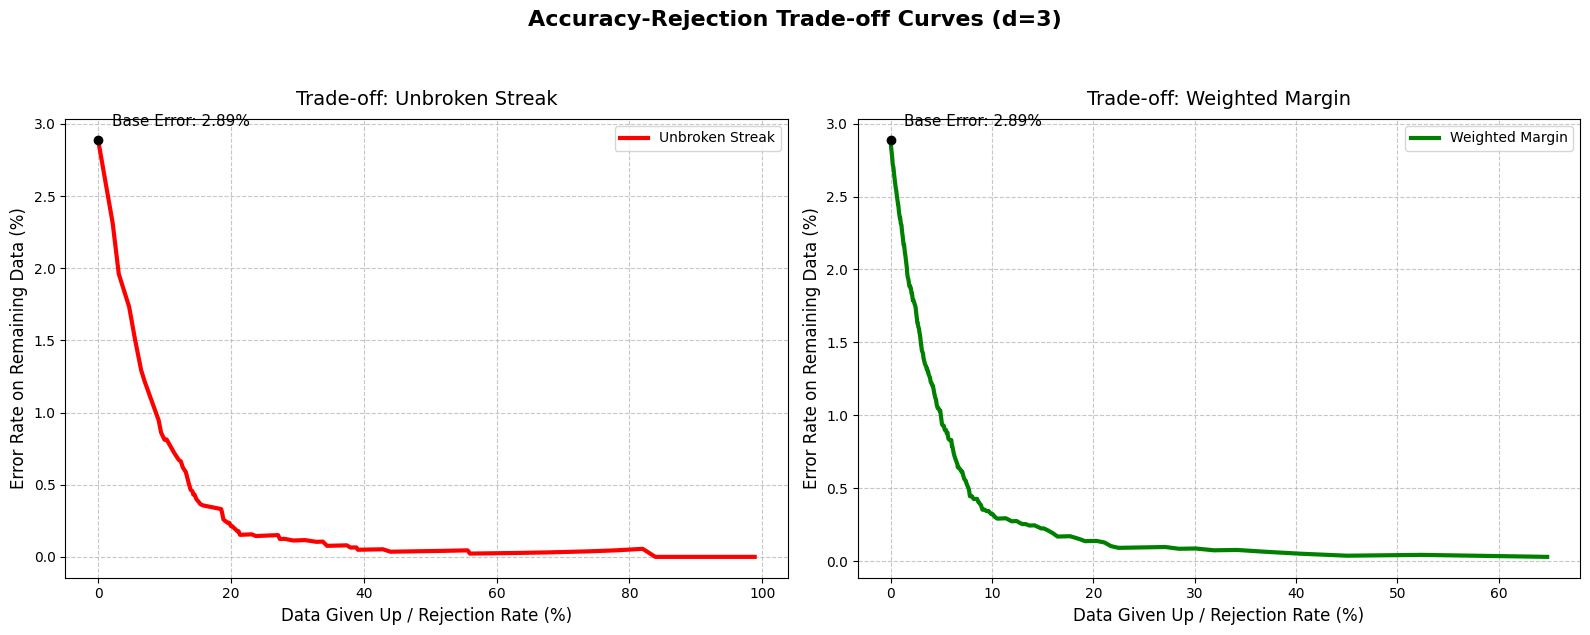


Training Multiclass | d=4, Epochs=1
  > Training completed in 39.8s | Total mistakes: 3367
  > Evaluation Complete in 3.7s
  > Test Set Accuracy: 97.32%


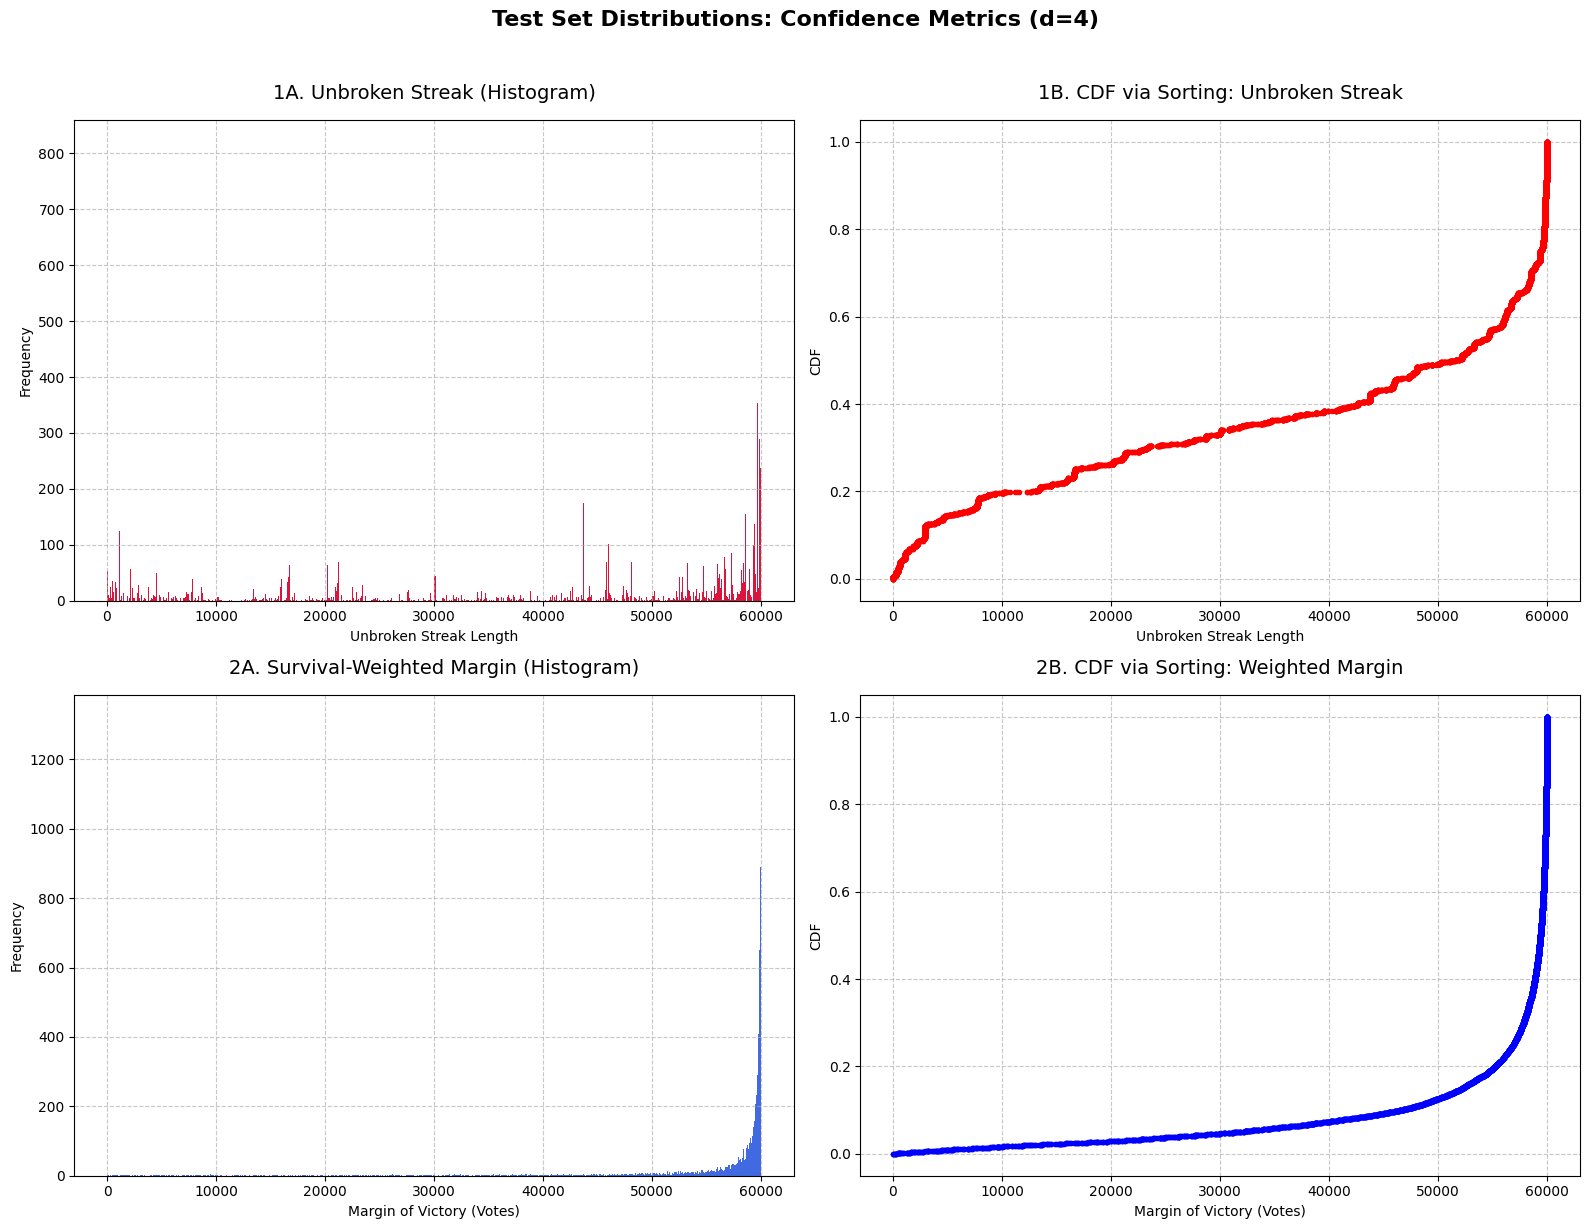

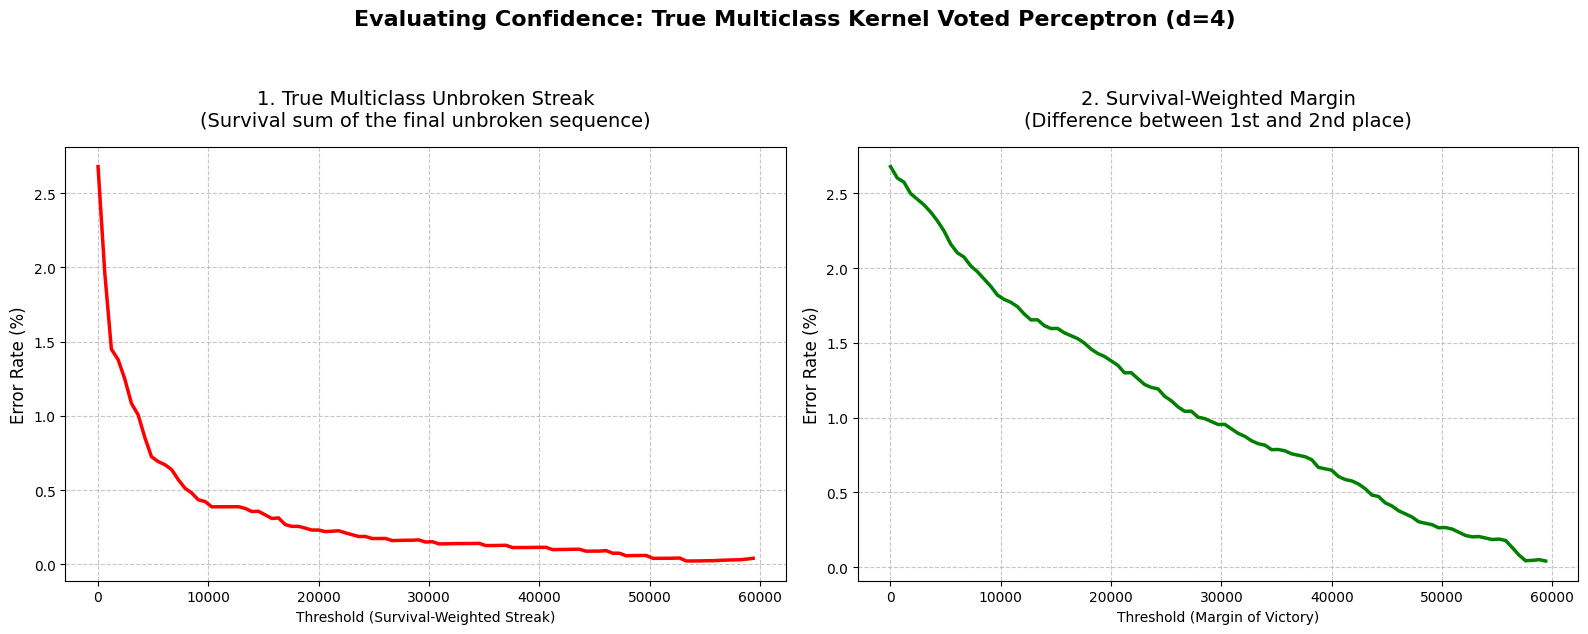

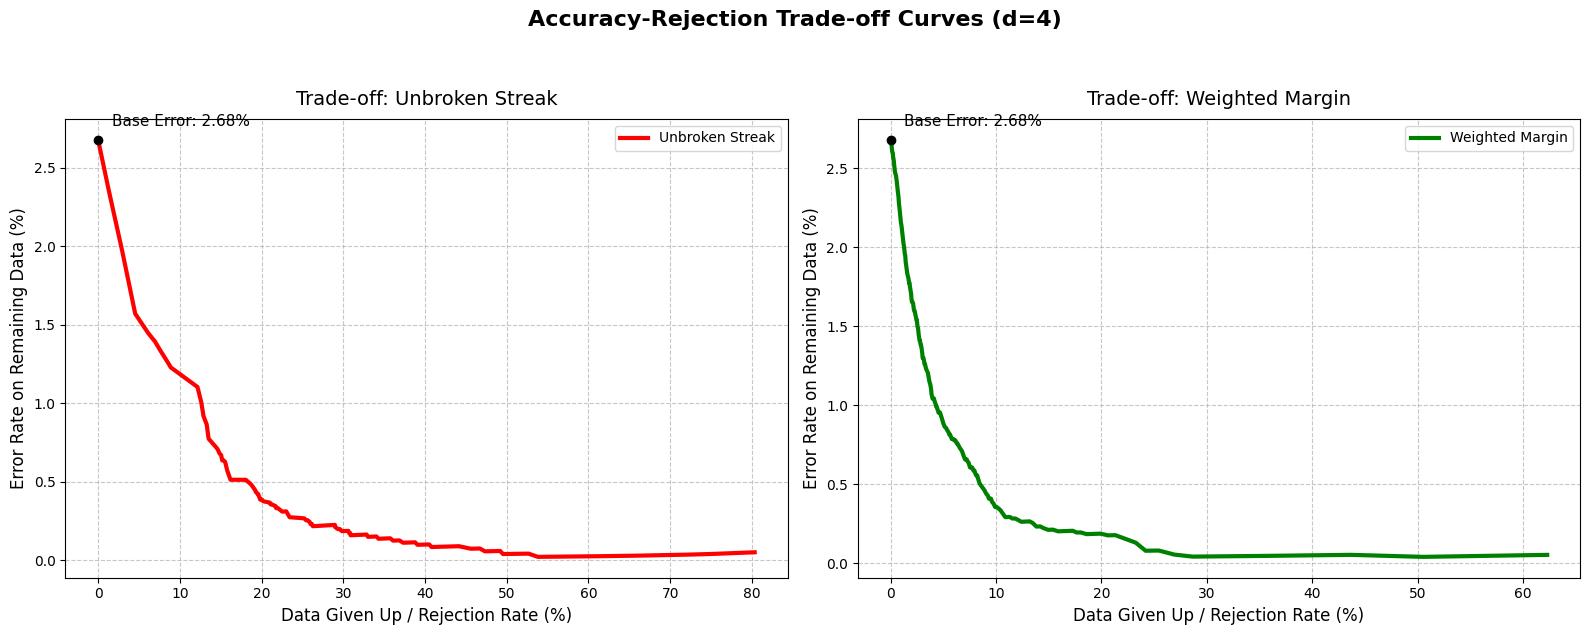


Training Multiclass | d=5, Epochs=1
  > Training completed in 39.2s | Total mistakes: 3260
  > Evaluation Complete in 3.7s
  > Test Set Accuracy: 97.29%


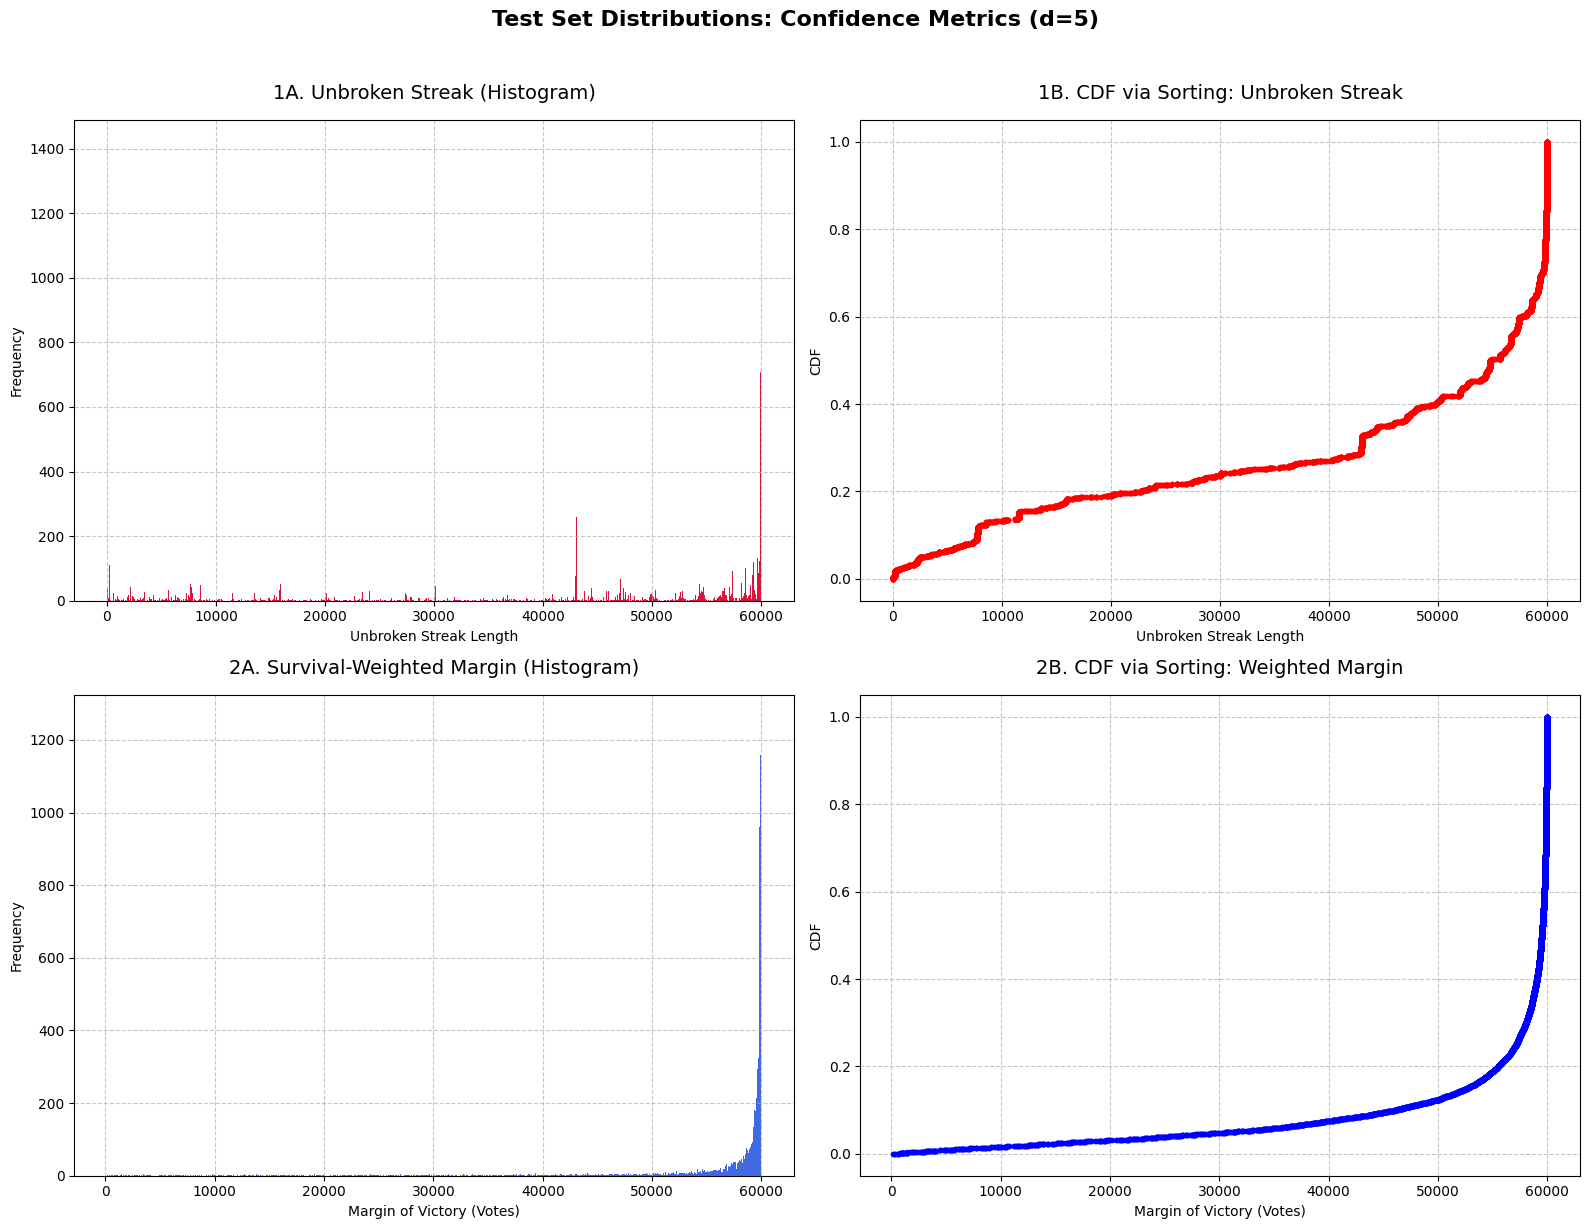

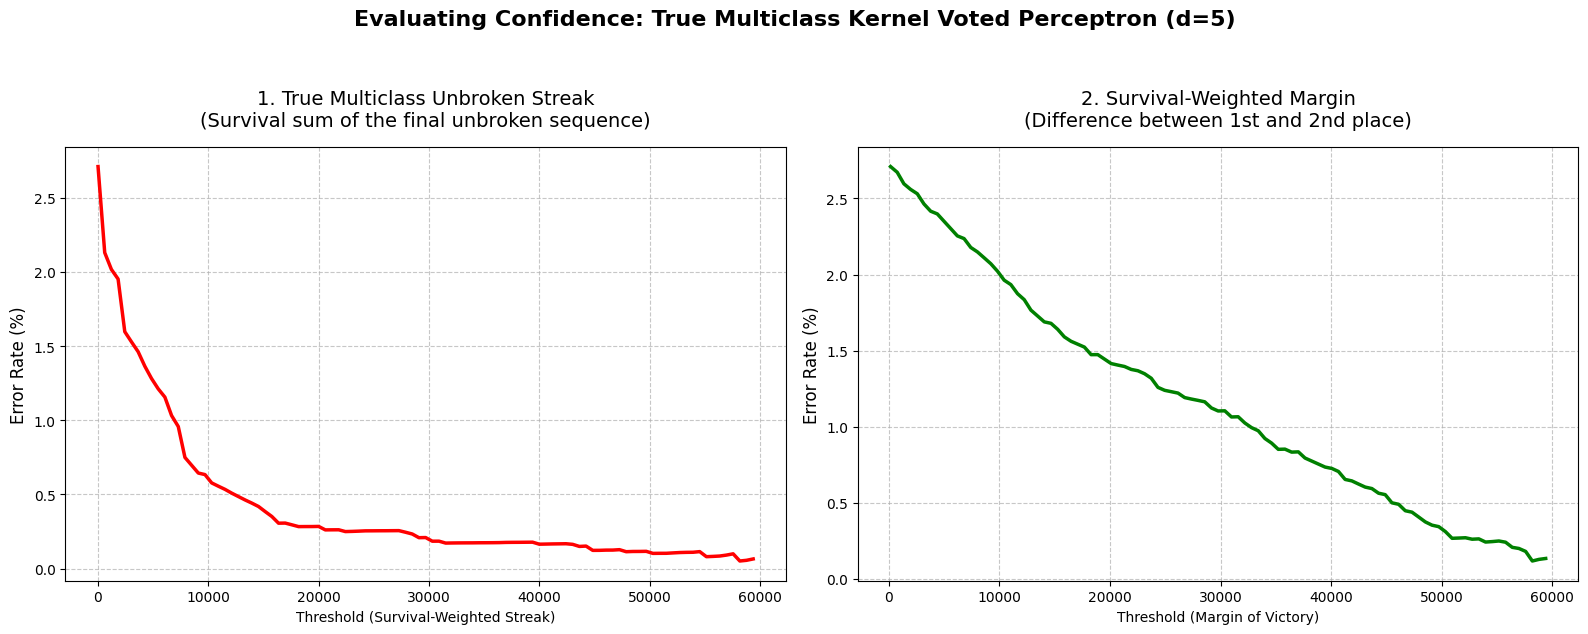

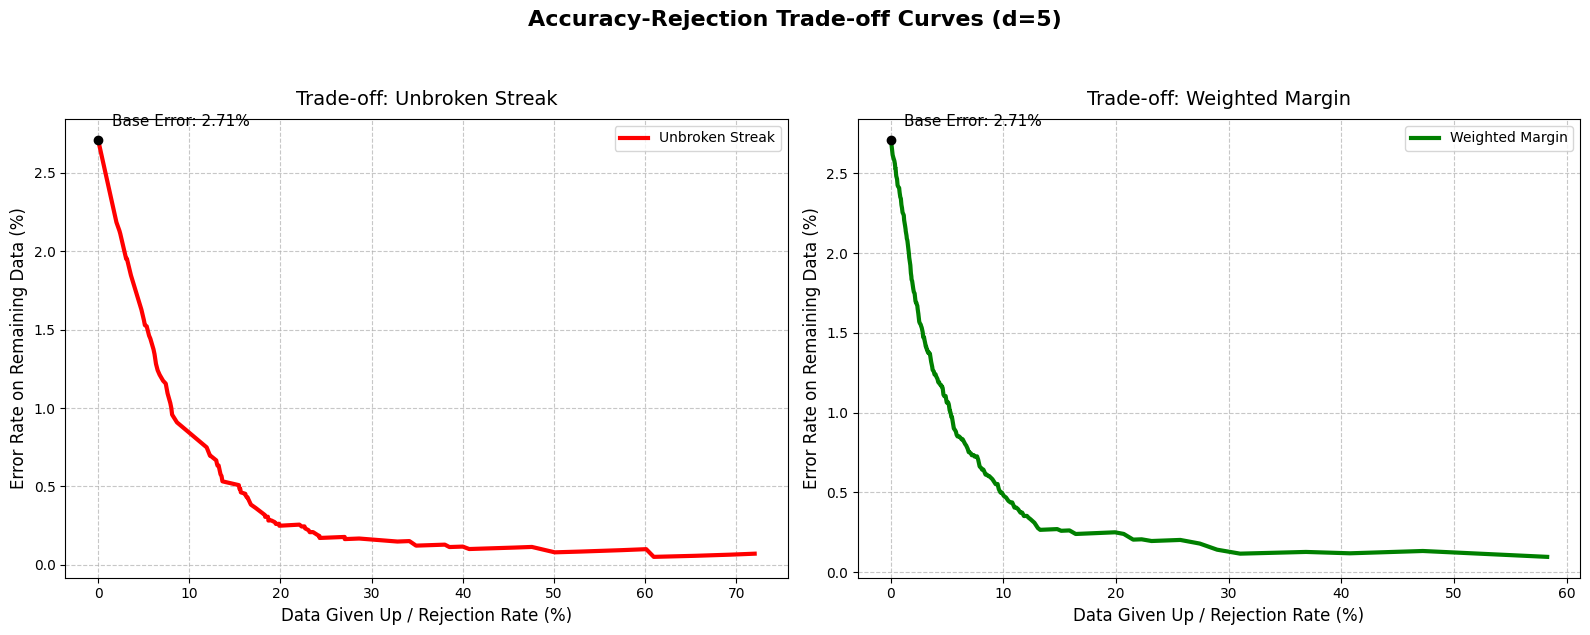


Training Multiclass | d=6, Epochs=1


In [ ]:
# Load the data once
X_train, X_test, y_train, y_test = load_and_preprocess_data()

DEGREES = [1, 2, 3, 4, 5, 6]
EPOCHS = 1

for d in DEGREES:
    print(f"\n============================================================")
    
    # 1. Train
    M_x, M_y_true, M_y_pred, C_vec, total_mistakes = train_voted_perceptron_multiclass(
        X_train, y_train, d=d, epochs=EPOCHS
    )
    
    # 2. Evaluate
    conf_streak, conf_weighted, mistakes_mask = evaluate_multiclass(
        X_test, y_test, M_x, M_y_true, M_y_pred, C_vec, d=d
    )
    
    accuracy = 100.0 * (1.0 - np.mean(mistakes_mask))
    print(f"  > Test Set Accuracy: {accuracy:.2f}%")
    
    # 3. Plot Distributions 
    plot_distributions(conf_streak, conf_weighted, d=d)
    
    # 4. Plot Calibration
    plot_calibration_multiclass(conf_streak, conf_weighted, mistakes_mask, d=d)
    
    # 5. Plot Trade-offs
    plot_rejection_vs_error(conf_streak, conf_weighted, mistakes_mask, d=d)